# Step 6: Cluster Profiling & Strategy — Real Values on Original Data

Notebooks 02–04 clustered on features transformed via **QuantileTransform + StandardScaler + ±3σ clipping** — an ideal space for Euclidean distance, but business-uninterpretable (what does an $AOV = 0.32$ mean?).

This notebook maps the **4 retail clusters** back to **original, interpretable units** (GBP, order count, days, percentages) computed directly on cleaned transactions, turning each segment into **actionable strategies**.






## Objectives

1. Compute **raw business KPIs** for each customer from raw transactions: LTV (revenue), frequency, AOV, unique SKUs, items per basket.
2. Include **raw behavioral features** (untransformed): Recency, MonthlyOrderRate, ReturnRate, QuarterConcentration, RepeatSKUFraction.
3. Aggregate by cluster using **medians** (robust to outliers) → profiling table.
4. Visualize: Pareto paradox (population vs. revenue), cluster fingerprints, core KPI comparisons.
5. Save customer-level profile + summary table, and formulate **segment-specific strategies** grounded in real metrics.


In [9]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append('../src')

from clustering_library import FeatureEngineer
from notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical
from visual_style import CLUSTER_COLORS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
sns.set_style('whitegrid')

ROOT = Path('../').resolve()
FIG_DIR = ROOT / 'figures' / '05_profiling'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Tên phân khúc theo cụm — KHÔNG đổi thứ tự (khớp 03_modeling)
SEGMENT_NAMES = {
    0: 'Seasonal Intensives',
    1: 'High-Return Actives',
    2: 'One-Time Explorers',
    3: 'Occasional Loyalists',
}
CLUSTER_ORDER = [0, 1, 2, 3]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Cleaned Raw Data and Cluster Labels

`cleaned_uk_data.csv` (output of notebook 01) is the raw transaction data; `cluster_assignments_retail_k4.csv` (output of notebook 03) assigns each retail customer to 1 of 4 clusters.


In [11]:
# Đọc từ sandbox nếu có (manual run), ngược lại đọc bản canonical.
data_path     = rpath('processed/cleaned_uk_data.csv')
raw_data_path = '../data/raw/online_retail.xlsx'

fe = FeatureEngineer(data_path, raw_data_path=raw_data_path)
df = fe.load_data()

assignments = pd.read_csv(rpath('processed/cluster_assignments_retail_k4.csv')).set_index('CustomerID')

print(f"Raw : {df.shape[0]:,} rows | {df['CustomerID'].nunique():,} UK customers")
print(f"Cluster labels : {len(assignments):,} retail customers across {assignments['cluster'].nunique()} clusters")
assignments['segment'].value_counts()

Raw : 354,321 rows | 3,920 UK customers
Cluster labels : 3,741 retail customers across 4 clusters


segment
One-Time Explorers      1257
High-Return Actives     1107
Occasional Loyalists    1047
Seasonal Intensives      330
Name: count, dtype: int64

## 2. Compute Raw Metrics per Customer

### (a) Business KPIs — computed directly from raw transactions, immediately interpretable:

| KPI | Meaning |
| --- | --- |
| `TotalRevenue` | LTV / Monetary — total spend |
| `NumOrders` | Frequency — distinct order count |
| `AOV` | Average order value |
| `AvgBasketItems` | Average items per basket |
| `NumUniqueSKU` | Purchased catalog breadth |

### (b) Raw Behavioral Features — reuse `FeatureEngineer` to retrieve the 5 core segmentation drivers (untransformed, in original units):
`Recency` (days), `MonthlyOrderRate`, `ReturnRate` (invoice cancellation rate), `QuarterConcentration`, `RepeatSKUFraction`.


In [12]:
# --- (a) KPI kinh doanh dễ diễn giải ---
g = df.groupby('CustomerID')
kpi = pd.DataFrame({
    'TotalRevenue': g['TotalPrice'].sum(),     # LTV / Monetary
    'NumOrders':    g['InvoiceNo'].nunique(),   # Frequency
    'NumUniqueSKU': g['StockCode'].nunique(),
    'TotalItems':   g['Quantity'].sum(),
})
kpi['AOV']            = kpi['TotalRevenue'] / kpi['NumOrders']
kpi['AvgBasketItems'] = kpi['TotalItems']  / kpi['NumOrders']

# --- (b) Đặc trưng hành vi THÔ (chưa transform) — tái dùng FeatureEngineer ---
fe.create_customer_features()   # điền fe.customer_feature_candidates (20 đặc trưng thô)
raw_feats = fe.customer_feature_candidates[
    ['Recency', 'MonthlyOrderRate', 'ReturnRate', 'QuarterConcentration', 'RepeatSKUFraction']
].copy()

# --- (c) Gộp KPI + đặc trưng thô + nhãn cụm (chỉ giữ khách retail đã gán cụm) ---
profiles = assignments[['cluster']].join(kpi, how='left').join(raw_feats, how='left')
profiles['segment'] = profiles['cluster'].map(SEGMENT_NAMES)

print(f"Hồ sơ khách hàng: {profiles.shape[0]:,} dòng × {profiles.shape[1]} cột")
assert profiles.drop(columns='segment').isna().sum().sum() == 0, 'Có giá trị thiếu!'
profiles.head()

Hồ sơ khách hàng: 3,741 dòng × 13 cột


,cluster,TotalRevenue,NumOrders,NumUniqueSKU,TotalItems,AOV,AvgBasketItems,Recency,MonthlyOrderRate,ReturnRate,QuarterConcentration,RepeatSKUFraction,segment
CustomerID,,,,,,,,,,,,,
12747,3,"4,196.01",11,42,1275,381.46,115.91,2,0.90,0.00,0.51,0.45,Occasional Loyalists
12748,1,"33,719.73",209,1768,25747,161.34,123.19,1,16.85,0.06,0.54,0.56,High-Return Actives
12749,1,"4,090.88",5,160,1471,818.18,294.20,4,0.72,0.38,0.46,0.23,High-Return Actives
12820,3,942.34,4,55,722,235.59,180.50,3,0.37,0.00,0.59,0.07,Occasional Loyalists
12821,2,92.72,1,6,70,92.72,70.00,214,1.00,0.00,1.00,0.00,One-Time Explorers


## 3. Cluster Profiling Table

Use **medians** for each metric (robust to outliers — a few VIP customers won't skew the entire cluster profile), along with population size and **revenue contribution** (total, not median).


In [13]:
profile_metrics = [
    'TotalRevenue', 'NumOrders', 'AOV', 'AvgBasketItems', 'NumUniqueSKU',
    'Recency', 'MonthlyOrderRate', 'ReturnRate', 'RepeatSKUFraction', 'QuarterConcentration',
]

summary = profiles.groupby('cluster')[profile_metrics].median()
summary.insert(0, 'n', profiles.groupby('cluster').size())
summary.insert(1, 'pct_customers', (summary['n'] / summary['n'].sum() * 100).round(1))

rev_by_cluster = profiles.groupby('cluster')['TotalRevenue'].sum()
summary.insert(2, 'revenue_total', rev_by_cluster.round(0))
summary.insert(3, 'pct_revenue', (rev_by_cluster / rev_by_cluster.sum() * 100).round(1))

summary.index = [f'C{c} · {SEGMENT_NAMES[c]}' for c in summary.index]
summary.T   # chuyển vị: chỉ số theo hàng, cụm theo cột → dễ so sánh

,C0 · Seasonal Intensives,C1 · High-Return Actives,C2 · One-Time Explorers,C3 · Occasional Loyalists
n,330.00,"1,107.00","1,257.00","1,047.00"
pct_customers,8.80,29.60,33.60,28.00
revenue_total,"276,786.00","4,899,020.00","423,340.00","1,314,317.00"
pct_revenue,4.00,70.90,6.10,19.00
TotalRevenue,605.32,"1,971.87",264.70,859.35
NumOrders,2.00,6.00,1.00,3.00
AOV,252.14,341.41,259.01,242.10
AvgBasketItems,144.17,197.75,144.00,143.42
NumUniqueSKU,35.00,77.00,17.00,50.00
Recency,36.50,23.00,125.00,37.00


## 4. Pareto Paradox — Population Size vs Revenue Contribution

The primary strategic question: **where is the money?** Compare customer share and revenue share for each cluster.


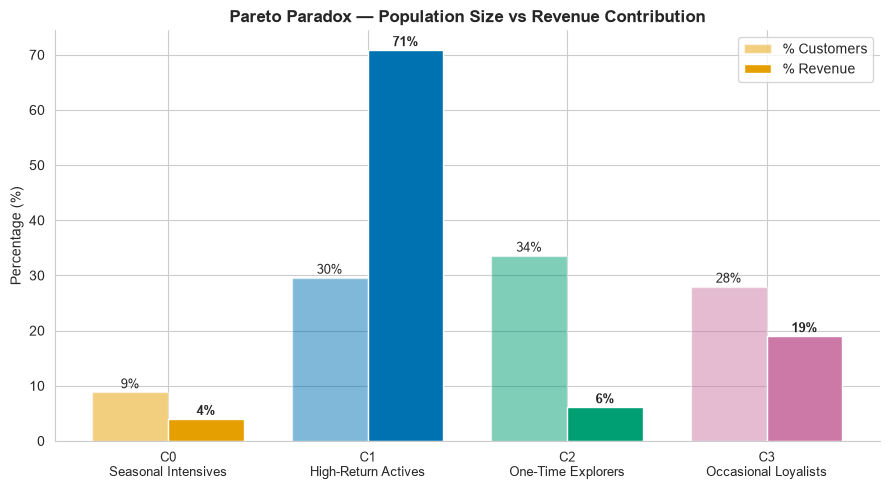

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(CLUSTER_ORDER)); w = 0.38
pop = [(profiles['cluster'] == c).mean() * 100 for c in CLUSTER_ORDER]
rev = [rev_by_cluster[c] / rev_by_cluster.sum() * 100 for c in CLUSTER_ORDER]
colors = [CLUSTER_COLORS[c] for c in CLUSTER_ORDER]

ax.bar(x - w/2, pop, w, label='% Customers', color=colors, alpha=0.5, edgecolor='white')
ax.bar(x + w/2, rev, w, label='% Revenue',  color=colors, edgecolor='white')
for i, (p, r) in enumerate(zip(pop, rev)):
    ax.text(i - w/2, p + 0.7, f'{p:.0f}%', ha='center', fontsize=9)
    ax.text(i + w/2, r + 0.7, f'{r:.0f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'C{c}\n{SEGMENT_NAMES[c]}' for c in CLUSTER_ORDER], fontsize=9)
ax.set_ylabel('Percentage (%)')
ax.set_title('Pareto Paradox — Population Size vs Revenue Contribution', fontweight='bold')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'population_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cluster Fingerprints

Median of each feature, **z-score normalized per feature** (across the 4 clusters) to highlight relative highs/lows. Color = normalized deviation; **annotated numbers = actual values (medians)**.


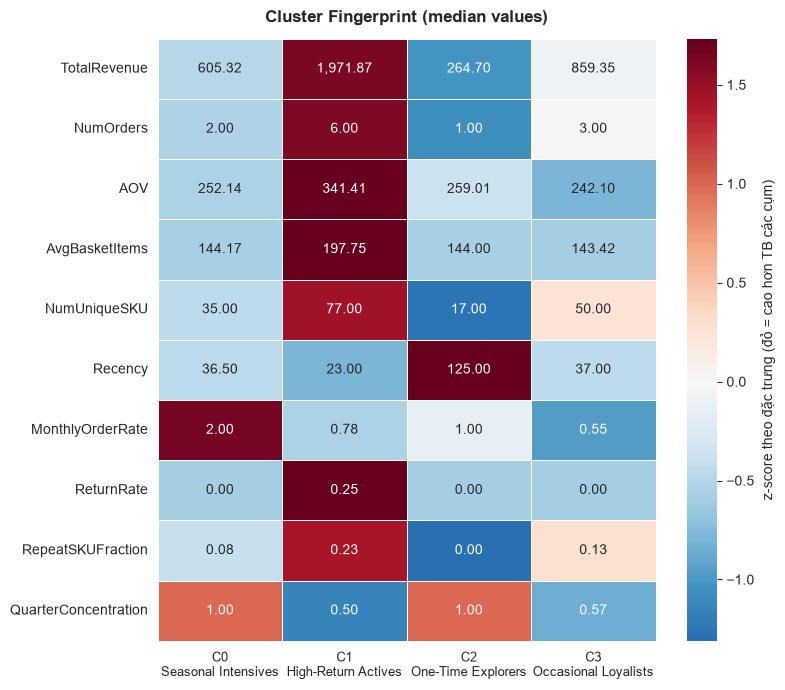

In [15]:
fp_metrics = [
    'TotalRevenue', 'NumOrders', 'AOV', 'AvgBasketItems', 'NumUniqueSKU',
    'Recency', 'MonthlyOrderRate', 'ReturnRate', 'RepeatSKUFraction', 'QuarterConcentration',
]
med = profiles.groupby('cluster')[fp_metrics].median().loc[CLUSTER_ORDER]
z = (med - med.mean()) / med.std(ddof=0)   # z-score theo cột (mỗi đặc trưng)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(z.T, annot=med.T, fmt=',.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'z-score theo đặc trưng (đỏ = cao hơn TB các cụm)'},
            linewidths=.5, linecolor='white', ax=ax)
ax.set_xticklabels([f'C{c}\n{SEGMENT_NAMES[c]}' for c in CLUSTER_ORDER], rotation=0, fontsize=9)
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title('Cluster Fingerprint (median values)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_fingerprint.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Compare Core 4 Business Metrics

LTV, frequency, recency (**medians**) and invoice cancellation rate (**mean** — since ReturnRate is highly skewed, median equals 0 in multiple clusters).


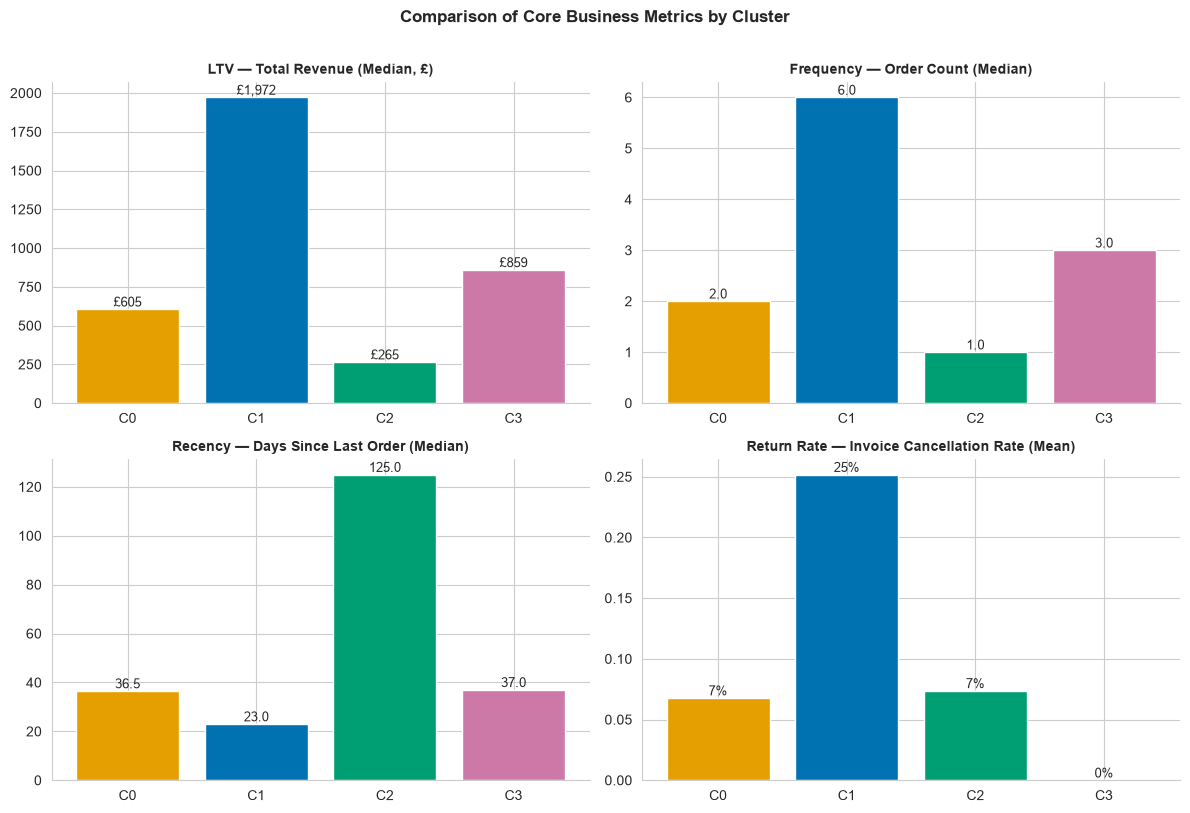

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
panels = [
    ('TotalRevenue', 'LTV — Total Revenue (Median, £)',             False),
    ('NumOrders',    'Frequency — Order Count (Median)',            False),
    ('Recency',      'Recency — Days Since Last Order (Median)',    False),
    ('ReturnRate',   'Return Rate — Invoice Cancellation Rate (Mean)', True),
]
for ax, (metric, title, use_mean) in zip(axes.ravel(), panels):
    vals = (profiles.groupby('cluster')[metric].mean() if use_mean
            else profiles.groupby('cluster')[metric].median()).loc[CLUSTER_ORDER]
    bars = ax.bar([f'C{c}' for c in CLUSTER_ORDER], vals.values,
                  color=[CLUSTER_COLORS[c] for c in CLUSTER_ORDER], edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    for b, v in zip(bars, vals.values):
        lbl = (f'{v:.0%}' if metric == 'ReturnRate'
               else f'£{v:,.0f}' if metric == 'TotalRevenue' else f'{v:,.1f}')
        ax.text(b.get_x() + b.get_width() / 2, v, lbl, ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparison of Core Business Metrics by Cluster', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kpi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Results

* `processed/cluster_customer_profiles.csv` — raw per-customer profiles (KPIs + features + cluster labels), used for downstream analytics / CRM integration.
* `processed/cluster_strategy_summary.csv` — cluster-level summary table.


In [17]:
prof_out  = profiles.reset_index()
prof_path = wpath('processed/cluster_customer_profiles.csv')
prof_out.to_csv(prof_path, index=False)

summ_path = wpath('processed/cluster_strategy_summary.csv')
summary.to_csv(summ_path)

print('Saved:')
print('  ', prof_path, f'({len(prof_out):,} dòng)')
print('  ', summ_path)

Saved:
   C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\data\_sandbox\processed\cluster_customer_profiles.csv (3,741 dòng)
   C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\data\_sandbox\processed\cluster_strategy_summary.csv


# 8. Segment-Specific Business Strategies

> Derived directly from the profiling table above — each recommendation is anchored in empirical data.

**The Pareto Picture:** `C1` represents only **~30% of customers** but generates **~71% of total revenue**. `C2` accounts for **~34% of customers** yet yields only **~6% of revenue**. Marketing budgets must be allocated based on customer value, not headcounts.

---

### 🟦 C1 · High-Return Actives — *Protect Revenue & Mitigate Returns* (Priority #1)
**Profile:** Median LTV **~£1,972** (highest), **6 orders**/customer, largest basket (**~198 items**), broadest catalog breadth (**~77 SKUs**), low recency (**~23 days** — highly active). **However, ReturnRate ~25%** — 1 out of every 4 invoices is cancelled/returned.  
**Generates ~71% of total revenue → any churn risk here is severely costly.**
- **Return Mitigation** = Highest profit leverage: improve product imagery, sizing charts, and descriptions for high-return SKUs; audit logistics and fulfillment errors.
- **VIP Tier & Retention:** Offer loyalty rewards, early-access drops, and dedicated account support for top-tier spenders.
- **Churn Early Warning:** Monitor individual recency triggers; execute automated interventions if order frequency drops below historical thresholds.

### 🟪 C3 · Occasional Loyalists — *Nurture to VIP* (Priority #2)
**Profile:** Median LTV **~£859**, **3 orders**, **ReturnRate ≈ 0%** (cleanest, most reliable cohort), recency **~37 days**, purchases evenly spread throughout the year (QuarterConcentration ~0.57).  
**~28% of customer base → ~19% of total revenue.** High profit margins with minimal return handling overhead.
- **Frequency Boost:** Deploy rhythmic email sequences, replenishment reminders, and historical cross-selling.
- **Progression to C1:** Incentivize basket expansion and higher order value; this is the lowest-CAC path to acquiring future VIPs.
- Low support cost — maintain consistent customer experience.

### 🟧 C0 · Seasonal Intensives — *Extend Lifecycle Beyond Peak* (Niche Market)
**Profile:** High MonthlyOrderRate (**~2 orders/month** during active windows) but **QuarterConcentration = 1.0** — concentrates 100% of spending within a single quarter and vanishes; LTV **~£605**, accounts for only **~4% of revenue** and **8.8% of customers**.
- **Pre-Season Activation:** Identify individual peak quarters and trigger targeted campaigns ahead of seasonal demand.
- **Break Seasonality:** Test off-season promotions and complementary product bundles to capture mid-year purchasing.
- Controlled ROI: Niche segment — avoid over-investing; focus on driving 1–2 incremental off-season orders.

### 🟩 C2 · One-Time Explorers — *Activate Second Purchase* (High Volume, Low Margin)
**Profile:** **Single purchase event**, recency **~125 days** (largely dormant), lowest median LTV **~£265**, minimal catalog breadth (**~17 SKUs**), QuarterConcentration = 1.0.  
**~34% of customer base but only ~6% of total revenue — binary trajectory: convert or churn.**
- **Post-Purchase Conversion:** Golden window immediately following transaction 1; issue time-sensitive repeat purchase offers or free shipping incentives.
- **Structured Onboarding:** Welcome series highlighting popular complementary categories based on initial transaction.
- **Cost Efficiency:** Most users are cold (recency ~125d) → restrict outreach to automated low-cost channels (email/retargeting), avoiding heavy blanket discount expenditure.

---

**Resource Allocation Framework:**

| Cluster | Strategic Role | Primary Action | Priority Level |
|---|---|---|:---:|
| **C1** High-Return Actives | Revenue Engine (~71%) | Mitigate returns + VIP retention | 🔴 Highest |
| **C3** Occasional Loyalists | Margin Foundation (~19%) | Increase purchase frequency + Upsell to C1 | 🟠 High |
| **C0** Seasonal Intensives | Niche Peak Spenders (~4%) | Pre-season triggers + Off-season activation | 🟡 Medium |
| **C2** One-Time Explorers | Top-of-Funnel Conversion (~6%) | Automated second-purchase triggers (Low-CAC) | 🟢 Selective |
